<a href="https://colab.research.google.com/github/camilodel02/Supervised-Learning/blob/main/Concurso1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lectura datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [ ]:
#data_train=pd.read_csv('/content/drive/MyDrive/Analítica/Reto 1 /train.csv')
#data_train.head(10)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
data_train=pd.read_csv('/content/train.csv')
data_train.head(10)

,idloc,edadloc,correo,paginas,telefono,impresa,servicio,nomina,idmercado,tamamer,promo,ropamujer
0,1648,11,10042,68,35,22609.49,30,66307,8,Grande,2,43747.69227
1,1259,3,11909,107,42,24561.99,35,29107,8,Grande,2,37483.68999
2,674,13,10669,75,33,38914.22,52,9519,4,Median,3,57522.99548
3,1558,7,6981,65,19,39204.97,30,28651,7,Grande,1,50338.06208
4,1626,22,10940,74,37,23947.08,46,30654,7,Grande,2,45675.55005
5,939,8,12689,110,55,29968.16,57,30528,7,Median,1,78428.06232
6,176,22,9773,73,34,26040.25,50,27890,8,Median,3,47451.43643
7,782,8,13018,106,45,35846.89,41,11107,3,Median,1,72545.45829
8,163,4,9546,84,39,24781.46,25,111305,7,Grande,2,18438.48108
9,1703,4,13050,112,46,21722.77,39,34739,9,Grande,1,49626.19215


In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   idloc      1600 non-null   int64  
 1   edadloc    1600 non-null   int64  
 2   correo     1600 non-null   int64  
 3   paginas    1600 non-null   int64  
 4   telefono   1600 non-null   int64  
 5   impresa    1600 non-null   float64
 6   servicio   1600 non-null   int64  
 7   nomina     1600 non-null   int64  
 8   idmercado  1600 non-null   int64  
 9   tamamer    1600 non-null   object 
 10  promo      1600 non-null   int64  
 11  ropamujer  1600 non-null   float64
dtypes: float64(2), int64(9), object(1)
memory usage: 150.1+ KB


In [ ]:
data_train.columns

Index(['idloc', 'edadloc', 'correo', 'paginas', 'telefono', 'impresa',
       'servicio', 'nomina', 'idmercado', 'tamamer', 'promo', 'ropamujer'],
      dtype='object')

## Exploratory Analysis

In [ ]:
# Nulls
data_train.isnull().sum()

,0
idloc,0
edadloc,0
correo,0
paginas,0
telefono,0
impresa,0
servicio,0
nomina,0
idmercado,0
tamamer,0


In [ ]:
print(data_train.describe())

             idloc      edadloc        correo      paginas     telefono  \
count  1600.000000  1600.000000   1600.000000  1600.000000  1600.000000   
mean    995.531875    10.469375  10598.675625    85.042500    37.637500   
std     577.536360     7.385588   2400.668832    15.935398     9.745792   
min       1.000000     1.000000   1147.000000    51.000000    17.000000   
25%     495.750000     4.000000   9644.250000    74.000000    30.000000   
50%     996.000000     9.000000  10480.000000    84.000000    36.000000   
75%    1495.250000    17.000000  11763.500000    98.000000    43.000000   
max    1998.000000    25.000000  15259.000000   114.000000    59.000000   

            impresa     servicio         nomina    idmercado        promo  \
count   1600.000000  1600.000000    1600.000000  1600.000000  1600.000000   
mean   28834.617337    43.651250   24104.131250     4.925000     1.976875   
std     6251.170239    13.241524   18217.352027     2.606458     0.749461   
min    18061.200

In [ ]:
data_train['idmercado'].unique()

array([8, 4, 7, 3, 9, 5, 1, 2, 6])

In [ ]:
data_train['promo'].unique()

array([2, 3, 1])

In [ ]:
print(data_train['idmercado'].value_counts())

idmercado
3    209
9    186
1    185
5    178
2    177
8    171
4    170
6    166
7    158
Name: count, dtype: int64


In [ ]:
print(data_train['idloc'].unique())

[1648 1259  674 ... 1685 1378 1655]


In [ ]:
print(data_train['idloc'].value_counts())

idloc
1412    1
716     1
1223    1
832     1
751     1
       ..
1558    1
1626    1
939     1
176     1
782     1
Name: count, Length: 1600, dtype: int64


In [ ]:
print(data_train.query('idloc < 25').sort_values('idloc'))

      idloc  edadloc  correo  paginas  telefono   impresa  servicio  nomina  \
1333      1        7    7978       73        34  22294.48        20   26780   
562       2        1    8029       65        24  27978.66        26   24789   
1196      3        6    7752       85        20  28949.65        22   25121   
66        4       10    8685       74        17  22642.27        21   27648   
1067      5        5    7847       87        30  27210.61        23   25982   
1099      6       25    7881       79        28  26632.96        22   25036   
1350      7        8    8121       72        27  30374.97        20   26079   
1421      8        1    7811       83        35  26794.79        15   29174   
516       9        7    8811       74        30  28589.74        16   27081   
870      10        8   10309      105        45  38738.65        29   25819   
303      11        1    8081       66        35  22723.68        22   28484   
864      12        1    8378       59        20  249

In [ ]:
print(data_train['tamamer'].unique())

['Grande' 'Median' 'Pequeño']


In [ ]:
data_train['edadloc'].unique()

array([11,  3, 13,  7, 22,  8,  4,  2, 23, 19, 20, 21,  5, 24, 18,  9,  1,
       25, 15, 14, 17, 16, 10,  6, 12])

## Data Cleansing

In [ ]:
# Convertir la variable categórica 'tamamer' a enteros
data_train['tamamer'] = data_train['tamamer'].map({'Pequeño': 1, 'Median': 2, 'Grande': 3})
print(data_train['tamamer'].unique())

[3 2 1]


In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   idloc      1600 non-null   int64  
 1   edadloc    1600 non-null   int64  
 2   correo     1600 non-null   int64  
 3   paginas    1600 non-null   int64  
 4   telefono   1600 non-null   int64  
 5   impresa    1600 non-null   float64
 6   servicio   1600 non-null   int64  
 7   nomina     1600 non-null   int64  
 8   idmercado  1600 non-null   int64  
 9   tamamer    1600 non-null   int64  
 10  promo      1600 non-null   int64  
 11  ropamujer  1600 non-null   float64
dtypes: float64(2), int64(10)
memory usage: 150.1 KB


### Feature Engineering

In [ ]:
data_train['total_paginas']=data_train['correo']*data_train['paginas']
#data_train['total_servicio']=data_train['telefono']

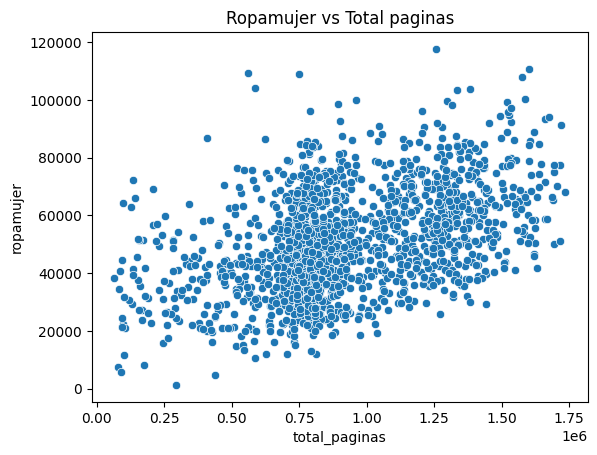

In [ ]:
sns.scatterplot(x=data_train['total_paginas'], y=data_train['ropamujer'])
plt.title(f'Ropamujer vs Total paginas')
plt.show()

## Descriptive Analysis

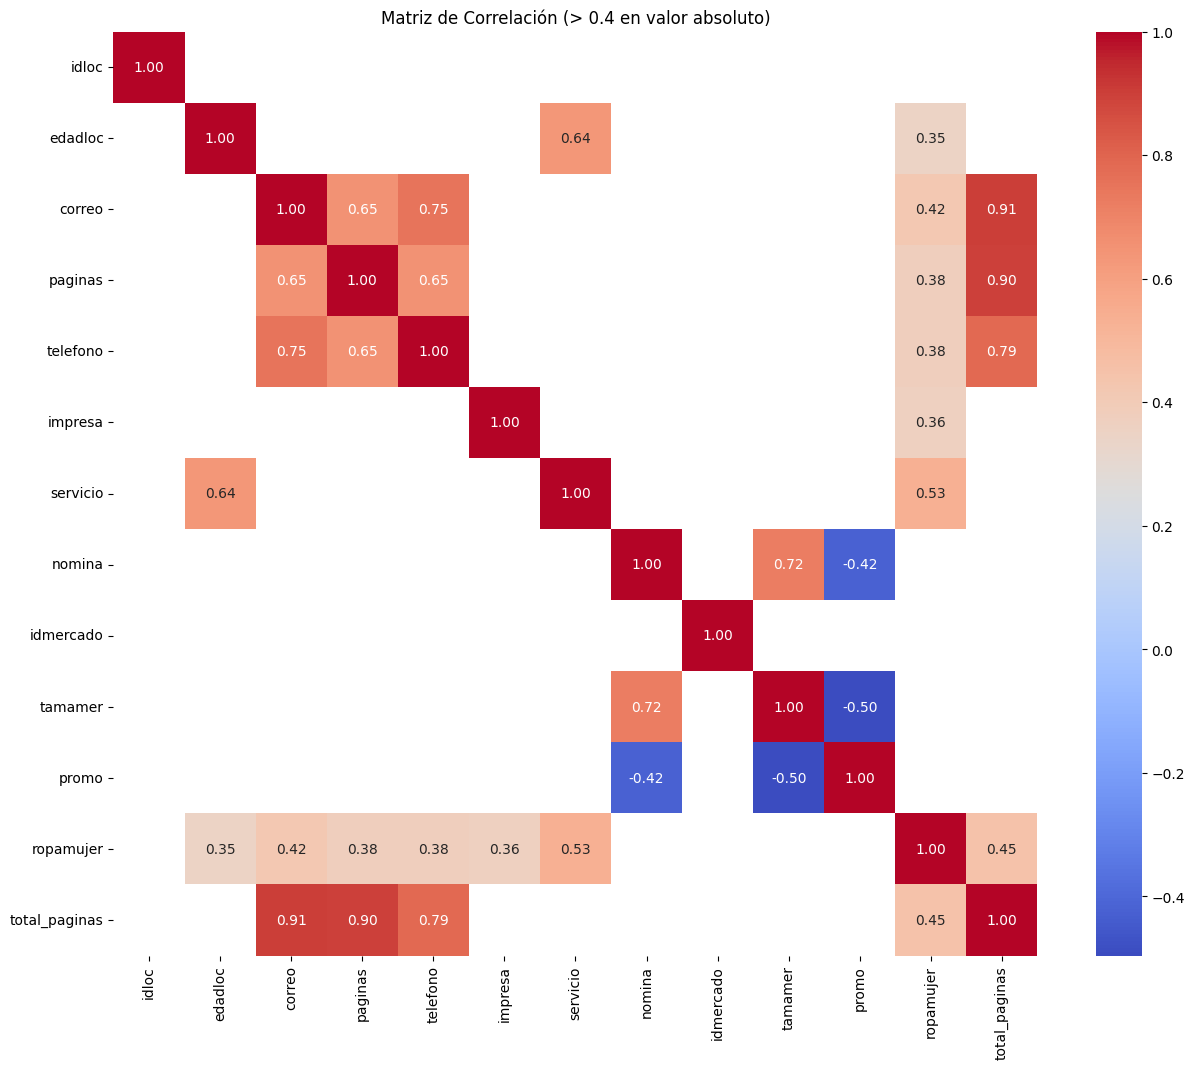

In [ ]:
## 1 Correlation Matrix
corr_matrix = data_train.corr()
filtered_matrix = corr_matrix.copy()
# Filtrar por las que tengan una correlación superior al 0.6
filtered_matrix[np.abs(filtered_matrix) <= 0.3] = np.nan

#Graficar
plt.figure(figsize=(15, 12))
sns.heatmap(filtered_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=filtered_matrix.isnull())
plt.title("Matriz de Correlación (> 0.4 en valor absoluto)")
plt.show()

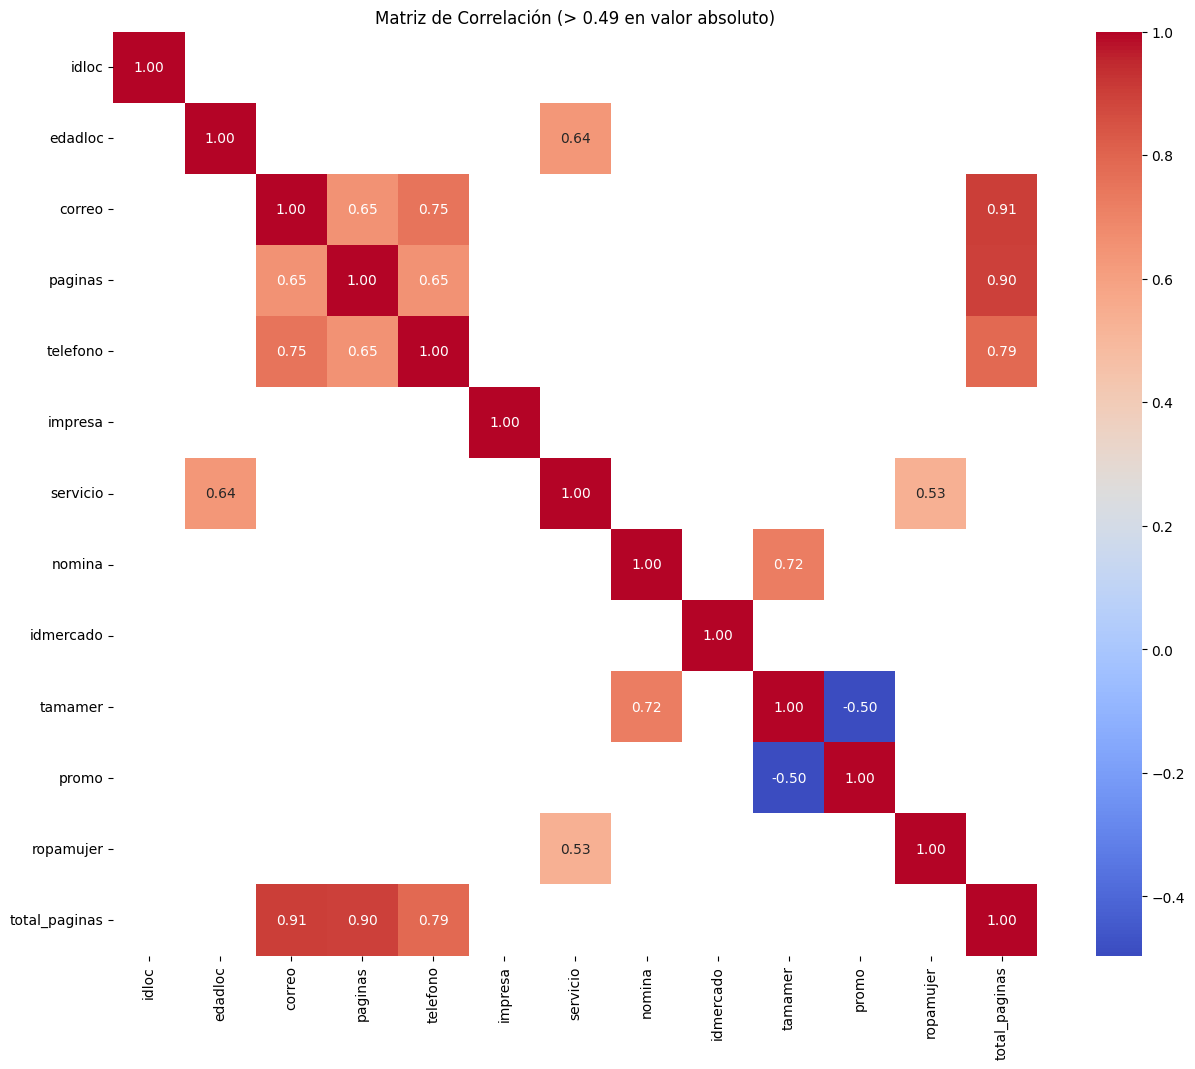

In [ ]:
## 1 Correlation Matrix
corr_matrix = data_train.corr()
filtered_matrix = corr_matrix.copy()
# Filtrar por las que tengan una correlación superior al 0.6
filtered_matrix[np.abs(filtered_matrix) <= 0.49] = np.nan

#Graficar
plt.figure(figsize=(15, 12))
sns.heatmap(filtered_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, mask=filtered_matrix.isnull())
plt.title("Matriz de Correlación (> 0.49 en valor absoluto)")
plt.show()


- Servicio es la única variable con una correlación lineal relativamente alta (superior al 0.50) con la variable ropamujer

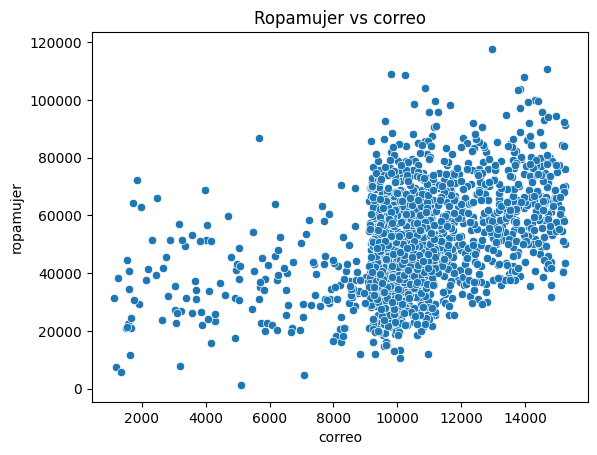

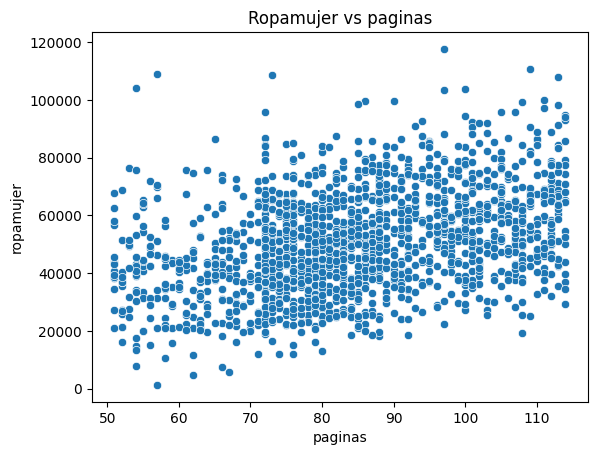

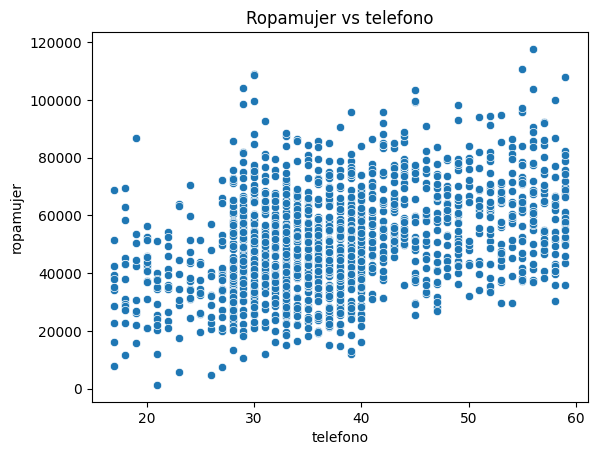

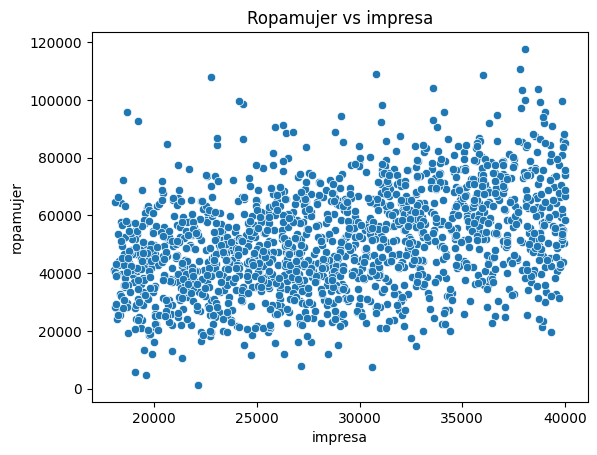

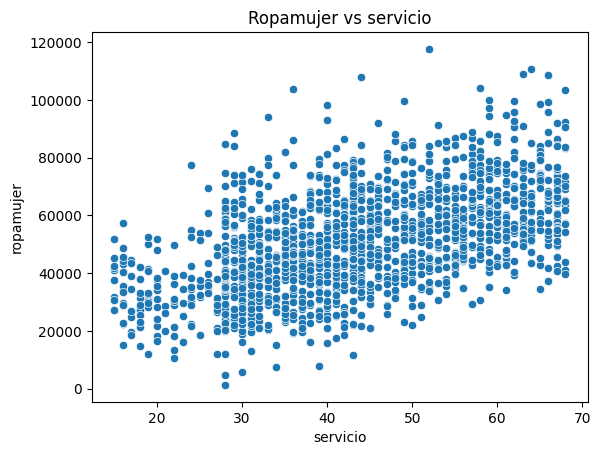

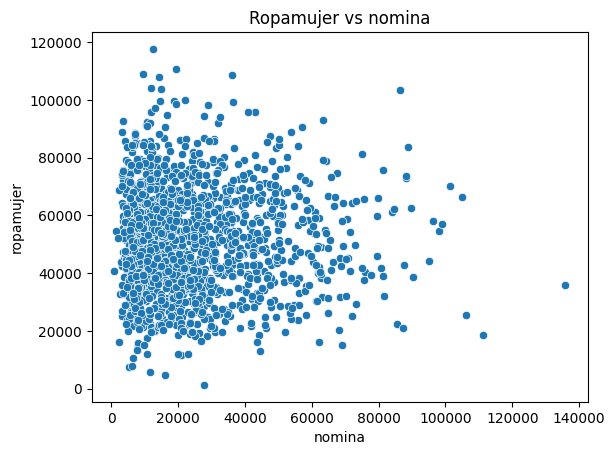

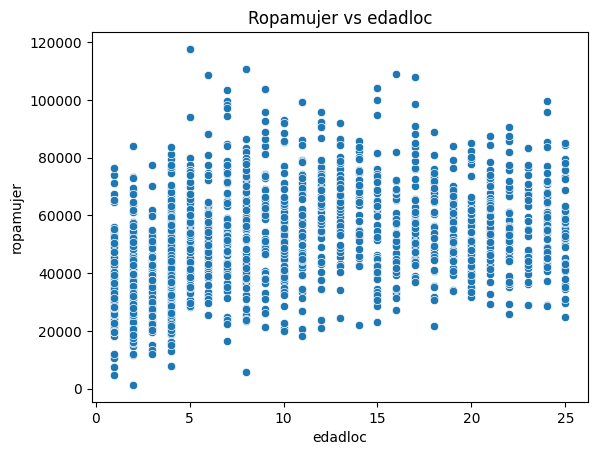

In [ ]:
#2 Scatter Plots para cada variable numérica diferente a los ID vs ropamujer para ver su relación
for col in ['correo', 'paginas', 'telefono', 'impresa', 'servicio', 'nomina', 'edadloc']:
    sns.scatterplot(x=data_train[col], y=data_train['ropamujer'])
    plt.title(f'Ropamujer vs {col}')
    plt.show()

Aparentemente las variables con una tendencia creciente y positiva con la variable ropamujer son:
- paginas
- telefono
- servicio
- correo (posiblemente, aunque hay una concentración más densa entre 9k y 14k)

In [ ]:
print(data_train.groupby('tamamer')['ropamujer'].mean())

tamamer
1    51063.477258
2    50847.179188
3    51039.208779
Name: ropamujer, dtype: float64


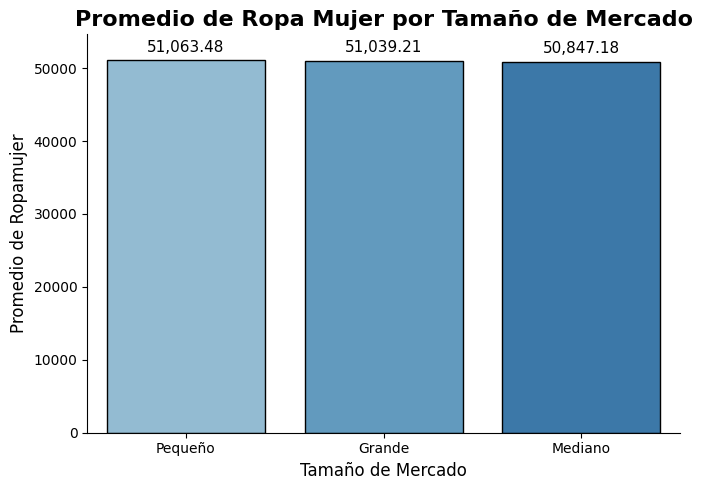

In [ ]:
#3 Promedios de ropamujer por tamaño del mercado

labels_dict = {1: 'Pequeño', 2: 'Mediano', 3: 'Grande'}
promedios = data_train.groupby('tamamer')['ropamujer'].mean()

#Crear DataFrame temporal para ordenar y asociar etiquetas
df_temp = promedios.reset_index()
df_temp['label'] = df_temp['tamamer'].map(labels_dict)
df_temp = df_temp.sort_values('ropamujer', ascending=False)

#Extraer listas ordenadas
ordered_labels = df_temp['label'].tolist()
ordered_values = df_temp['ropamujer'].tolist()

# Paleta azul suave ordenada
colors = sns.color_palette("Blues", n_colors=6)[2:5]
# Si hay más o menos de 3 categorías, ajustar:
colors = colors[:len(ordered_labels)]

# Crear gráfico ordenado
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=ordered_labels, y=ordered_values, palette=colors, edgecolor='black', hue=ordered_labels, legend = False)

# Títulos y ejes
plt.title('Promedio de Ropa Mujer por Tamaño de Mercado', fontsize=16, fontweight='bold')
plt.ylabel('Promedio de Ropamujer', fontsize=12)
plt.xlabel('Tamaño de Mercado', fontsize=12)

# Etiquetas de valores
for i, valor in enumerate(ordered_values):
    ax.text(i, valor + max(ordered_values)*0.015, f"{valor:,.2f}", ha='center', va='bottom', fontsize=11, color='black')

plt.ylim(0, max(ordered_values) + max(ordered_values)*0.07)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
print(data_train.groupby('idmercado')['ropamujer'].mean())

idmercado
1    48358.332624
2    50112.012600
3    51480.953306
4    51098.840487
5    51686.355389
6    50697.174540
7    54929.335940
8    51121.157944
9    49819.968233
Name: ropamujer, dtype: float64


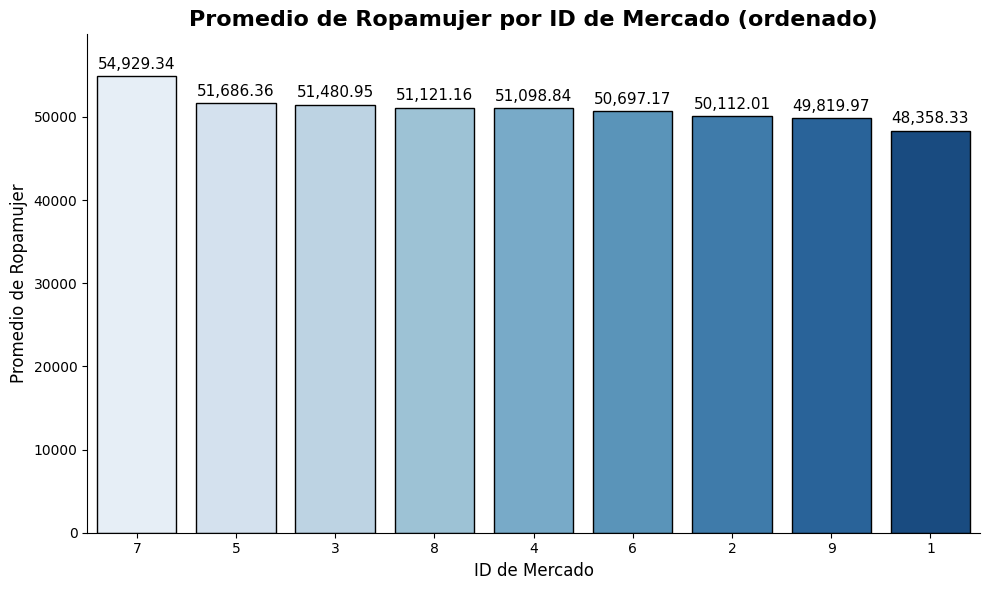

In [ ]:
# 4 promedios de ropamujer por ID de mercado
# Agrupar y ordenar promedios por ropamujer (de mayor a menor)
promedios = data_train.groupby('idmercado')['ropamujer'].mean().reset_index()
promedios_sorted = promedios.sort_values('ropamujer', ascending=False)

# Crear paleta del mismo tamaño que el número de barras
colors = sns.color_palette("Blues", n_colors=len(promedios_sorted))

# Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=promedios_sorted['idmercado'].astype(str),  # etiquetas reales (1–9)
                 y=promedios_sorted['ropamujer'],
                 palette=colors,
                 edgecolor='black',
                 hue=promedios_sorted['idmercado'].astype(str),
                 legend=False)

#  Título y etiquetas
plt.title('Promedio de Ropamujer por ID de Mercado (ordenado)', fontsize=16, fontweight='bold')
plt.ylabel('Promedio de Ropamujer', fontsize=12)
plt.xlabel('ID de Mercado', fontsize=12)

# Etiquetas de valor encima de cada barra
for i, valor in enumerate(promedios_sorted['ropamujer']):
    ax.text(i, valor + 500, f"{valor:,.2f}", ha='center', va='bottom', fontsize=11)

# Ajustes finales
plt.ylim(0, max(promedios_sorted['ropamujer']) + 5000)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
print(data_train.groupby('promo')['ropamujer'].mean())

promo
1    51265.430558
2    50816.708531
3    50929.640647
Name: ropamujer, dtype: float64


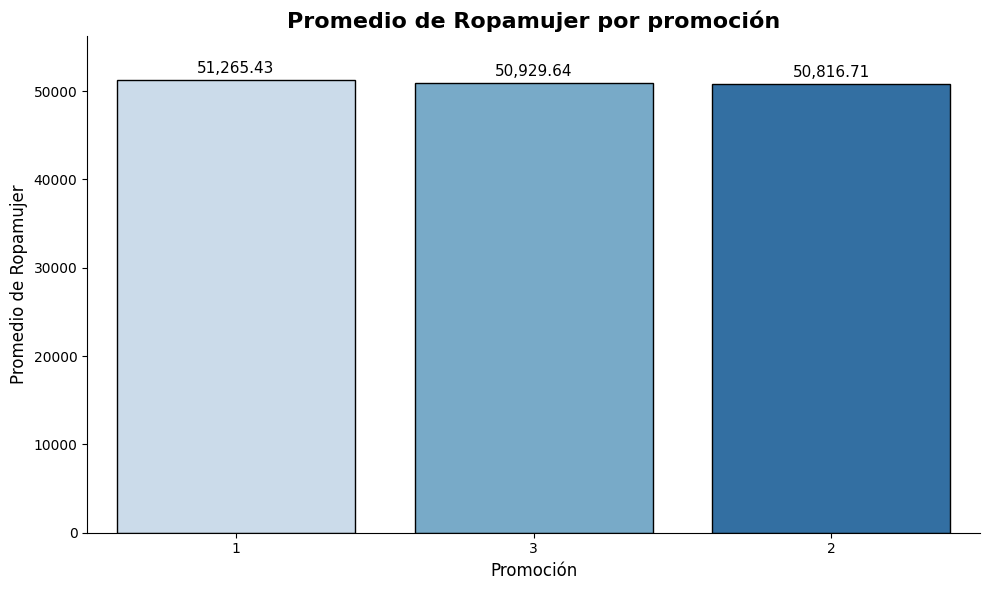

In [ ]:
#5 promedios de ropamujer por promo
# Agrupar y ordenar promedios por ropamujer (de mayor a menor)
promedios = data_train.groupby('promo')['ropamujer'].mean().reset_index()
promedios_sorted = promedios.sort_values('ropamujer', ascending=False)

#Crear paleta del mismo tamaño que el número de barras
colors = sns.color_palette("Blues", n_colors=len(promedios_sorted))

#Crear gráfico
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=promedios_sorted['promo'].astype(str),  # etiquetas reales (1–9)
                 y=promedios_sorted['ropamujer'],
                 palette=colors,
                 edgecolor='black',
                 hue=promedios_sorted['promo'].astype(str),
                 legend=False)

# Título y etiquetas
plt.title('Promedio de Ropamujer por promoción', fontsize=16, fontweight='bold')
plt.ylabel('Promedio de Ropamujer', fontsize=12)
plt.xlabel('Promoción', fontsize=12)

# Etiquetas de valor encima de cada barra
for i, valor in enumerate(promedios_sorted['ropamujer']):
    ax.text(i, valor + 500, f"{valor:,.2f}", ha='center', va='bottom', fontsize=11)

# Ajustes finales
plt.ylim(0, max(promedios_sorted['ropamujer']) + 5000)
sns.despine()
plt.tight_layout()
plt.show()

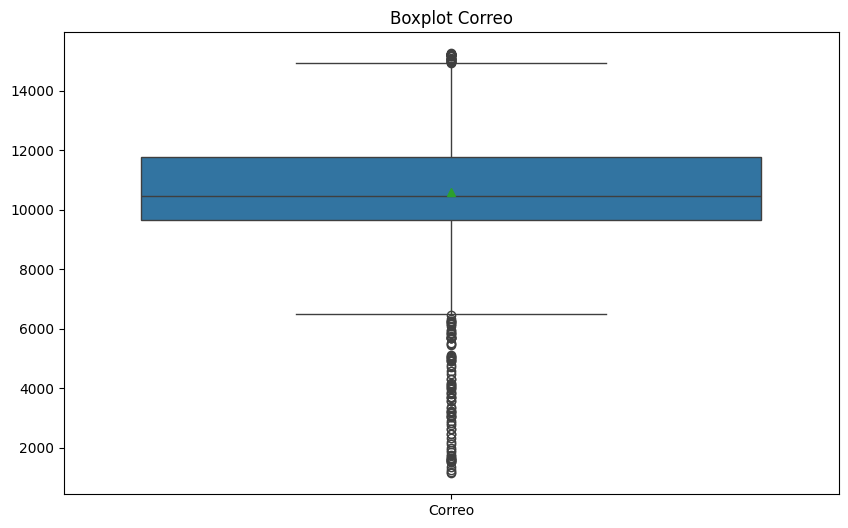

In [ ]:
#6 Boxplots para ver la distribucion de cada variable numérica (se excluyen las categóricas y los ID)
plt.figure(figsize=(10,6))
datos=data_train[['correo']]
sns.boxplot(data=datos, showmeans = True)
plt.xticks([0], ["Correo"])
plt.title("Boxplot Correo")
plt.show()

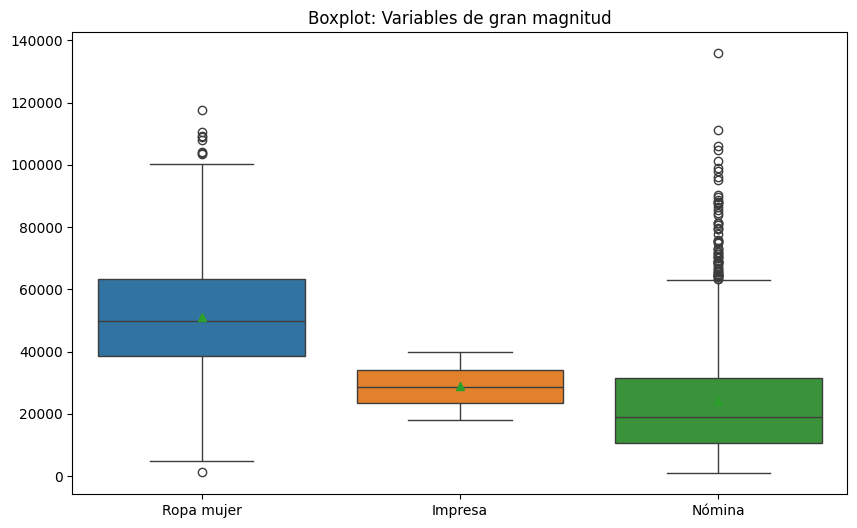

In [ ]:
#7 boxplots for bigger variables
plt.figure(figsize=(10,6))
datos=data_train[['ropamujer', 'impresa','nomina']]
sns.boxplot(data=datos, showmeans = True)
plt.xticks([0, 1, 2], ["Ropa mujer", "Impresa", "Nómina"])
plt.title("Boxplot: Variables de gran magnitud")
plt.show()

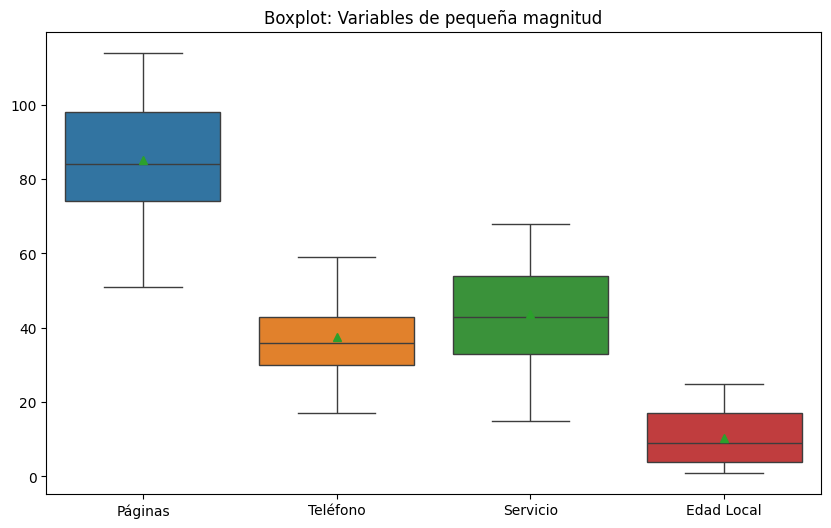

In [ ]:
#8
plt.figure(figsize=(10,6))
datos=data_train[['paginas', 'telefono', 'servicio', 'edadloc']]
sns.boxplot(data=datos, showmeans = True)
plt.xticks([0, 1, 2, 3], ["Páginas", "Teléfono", "Servicio", "Edad Local"])
plt.title("Boxplot: Variables de pequeña magnitud")
plt.show()


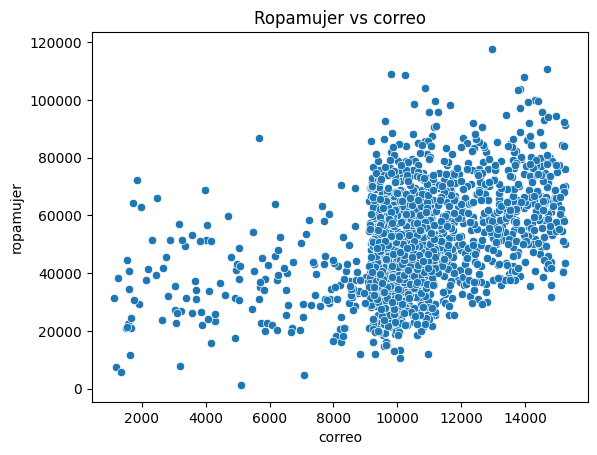

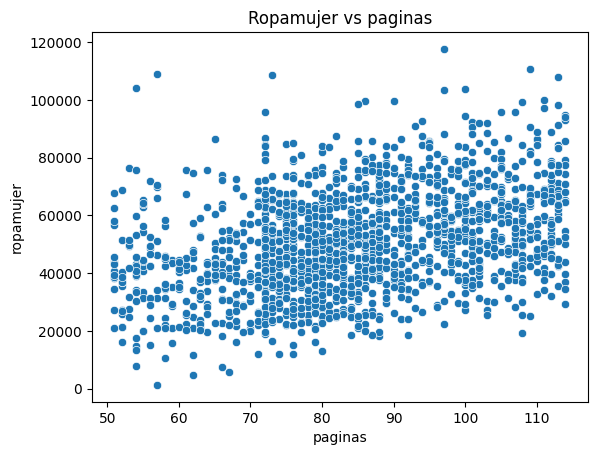

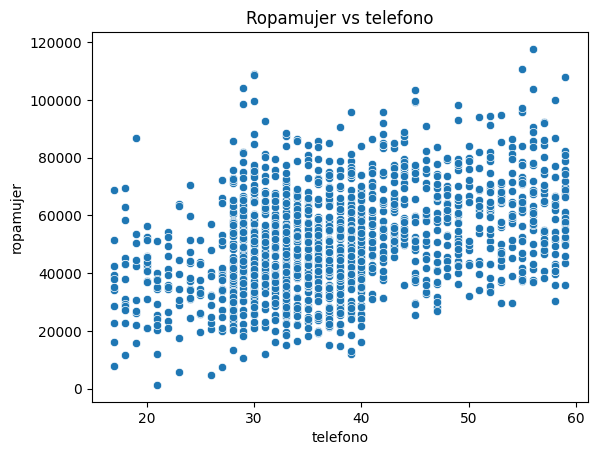

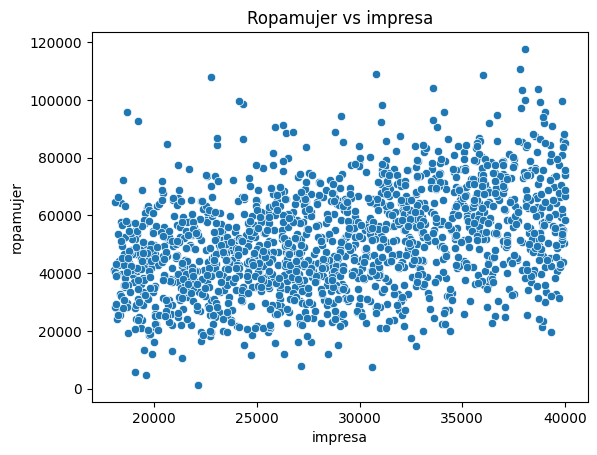

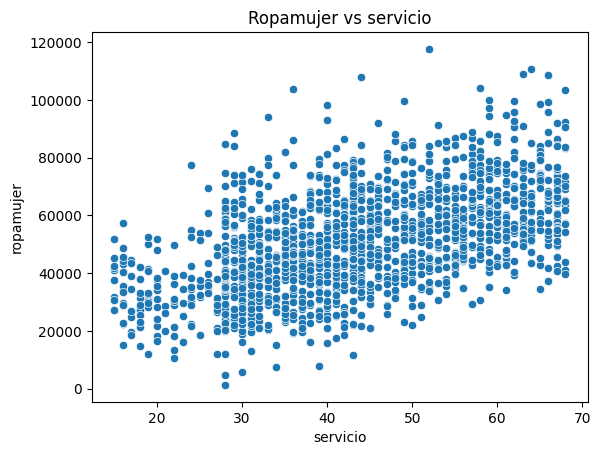

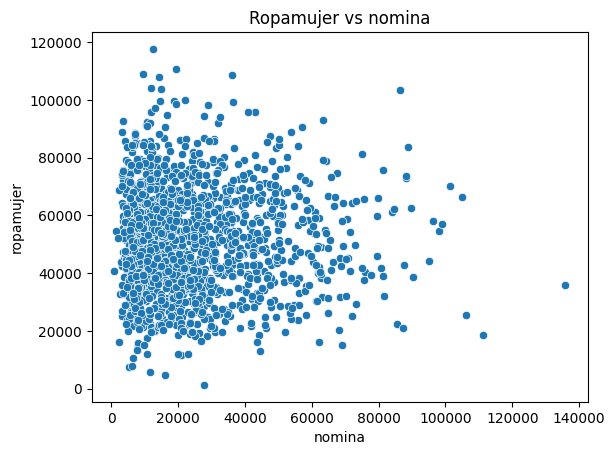

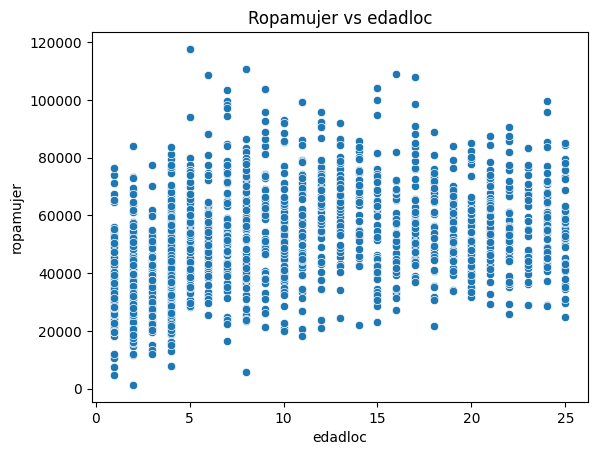

In [ ]:
# 9 Dispersión de las variables
for col in ['correo', 'paginas', 'telefono', 'impresa', 'servicio', 'nomina', 'edadloc']:
    sns.scatterplot(x=data_train[col], y=data_train['ropamujer'])
    plt.title(f'Ropamujer vs {col}')
    plt.show()

## One hot Encoding

In [ ]:
#One hot coding for promo variable
data_train = pd.get_dummies(data_train, columns=['promo'], prefix=['promo'], dtype='int64')
data_train= pd.get_dummies(data_train, columns=['idmercado'], prefix=['idmercado'], dtype='int64')

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   idloc          1600 non-null   int64  
 1   edadloc        1600 non-null   int64  
 2   correo         1600 non-null   int64  
 3   paginas        1600 non-null   int64  
 4   telefono       1600 non-null   int64  
 5   impresa        1600 non-null   float64
 6   servicio       1600 non-null   int64  
 7   nomina         1600 non-null   int64  
 8   tamamer        1600 non-null   int64  
 9   ropamujer      1600 non-null   float64
 10  total_paginas  1600 non-null   int64  
 11  promo_1        1600 non-null   int64  
 12  promo_2        1600 non-null   int64  
 13  promo_3        1600 non-null   int64  
 14  idmercado_1    1600 non-null   int64  
 15  idmercado_2    1600 non-null   int64  
 16  idmercado_3    1600 non-null   int64  
 17  idmercado_4    1600 non-null   int64  
 18  idmercad

In [ ]:
data_train.head()

,idloc,edadloc,correo,paginas,telefono,impresa,servicio,nomina,tamamer,ropamujer,...,promo_3,idmercado_1,idmercado_2,idmercado_3,idmercado_4,idmercado_5,idmercado_6,idmercado_7,idmercado_8,idmercado_9
0,1648,11,10042,68,35,22609.49,30,66307,3,43747.69227,...,0,0,0,0,0,0,0,0,1,0
1,1259,3,11909,107,42,24561.99,35,29107,3,37483.68999,...,0,0,0,0,0,0,0,0,1,0
2,674,13,10669,75,33,38914.22,52,9519,2,57522.99548,...,1,0,0,0,1,0,0,0,0,0
3,1558,7,6981,65,19,39204.97,30,28651,3,50338.06208,...,0,0,0,0,0,0,0,1,0,0
4,1626,22,10940,74,37,23947.08,46,30654,3,45675.55005,...,0,0,0,0,0,0,0,1,0,0


##Log

In [ ]:
#data_train['ropamujer'] = np.log1p(data_train['ropamujer'])  # log(ropamujer + 1) para manejar valores 0
data_train['impresa'] = np.log1p(data_train['impresa'])  # log(impresa + 1) para manejar valores 0
data_train['nomina'] = np.log1p(data_train['nomina'])  # log(nomina + 1) para manejar valores 0

## Outliers

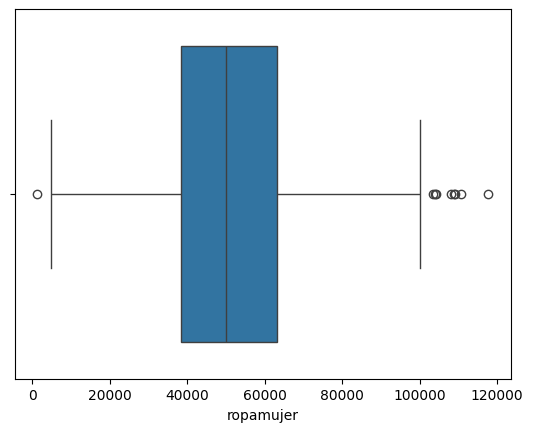

In [ ]:
# Identificar outliers con boxplot
sns.boxplot(x=data_train['ropamujer'])
plt.show()

# Calcular el rango intercuartílico (IQR) y eliminar outliers
Q1 = data_train['ropamujer'].quantile(0.25)
Q3 = data_train['ropamujer'].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = (data_train['ropamujer'] < (Q1 - 1.5 * IQR)) | (data_train['ropamujer'] > (Q3 + 1.5 * IQR))

# Eliminar outliers
data_train = data_train[~outlier_condition]

imprimir cuantos datos quedaron

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1591 entries, 0 to 1599
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   idloc          1591 non-null   int64  
 1   edadloc        1591 non-null   int64  
 2   correo         1591 non-null   int64  
 3   paginas        1591 non-null   int64  
 4   telefono       1591 non-null   int64  
 5   impresa        1591 non-null   float64
 6   servicio       1591 non-null   int64  
 7   nomina         1591 non-null   float64
 8   tamamer        1591 non-null   int64  
 9   ropamujer      1591 non-null   float64
 10  total_paginas  1591 non-null   int64  
 11  promo_1        1591 non-null   int64  
 12  promo_2        1591 non-null   int64  
 13  promo_3        1591 non-null   int64  
 14  idmercado_1    1591 non-null   int64  
 15  idmercado_2    1591 non-null   int64  
 16  idmercado_3    1591 non-null   int64  
 17  idmercado_4    1591 non-null   int64  
 18  idmercado_5  

#Test

In [ ]:
#data_test=pd.read_csv('/content/drive/MyDrive/Analítica/Reto 1 /test.csv')
#data_test.head(10)

In [ ]:
data_test=pd.read_csv('/content/test.csv')
data_test.head(10)

,idloc,edadloc,correo,paginas,telefono,impresa,servicio,nomina,idmercado,tamamer,promo,ropamujer
0,22,3,9115,65,30,26496.36,27,21936,2,Grande,3,NaN
1,14,18,8438,82,35,20911.52,22,25542,1,Grande,2,NaN
2,91,5,11890,92,50,24474.30,53,18591,9,Grande,1,NaN
3,32,20,9003,54,27,33446.10,26,23028,2,Grande,3,NaN
4,28,8,9152,91,24,27234.64,22,20214,2,Grande,3,NaN
5,109,15,8697,88,34,25929.75,26,23192,2,Grande,1,NaN
6,46,11,9731,80,33,29018.32,33,21827,4,Pequeño,1,NaN
7,82,11,11096,87,43,31720.31,36,17425,8,Median,2,NaN
8,55,7,10078,66,27,31539.69,37,19664,5,Grande,2,NaN
9,45,5,10206,88,32,34386.65,35,22526,4,Pequeño,1,NaN


In [ ]:
print(data_test['idloc'].unique())

[  22   14   91   32   28  109   46   82   55   45   69   86   30   99
  115  100  123  127  130  131  132  133  137  138  140  147  154  158
  161  164  181  183  194  202  204  210  232  240  242  244  251  259
  263  270  271  274  277  279  283  289  294  295  299  303  306  307
  308  318  329  331  335  336  345  346  350  353  355  356  365  370
  371  372  373  375  377  382  386  387  388  396  400  402  405  410
  427  439  440  442  457  461  462  467  468  471  487  498  499  509
  518  529  530  535  536  537  538  539  544  548  562  563  569  575
  578  579  581  583  584  585  589  590  591  595  597  609  614  630
  633  636  641  642  645  648  654  655  669  682  712  731  735  739
  740  742  745  750  757  758  760  767  768  769  780  783  792  796
  801  803  808  812  813  815  820  822  826  837  852  854  855  858
  869  876  879  889  890  898  906  912  916  917  922  923  926  932
  934  937  938  940  948  955  956  965  974  975  981  984  994  996
 1001 

In [ ]:
print(data_test['idloc'].value_counts())

idloc
2000    1
22      1
14      1
91      1
32      1
       ..
131     1
132     1
133     1
137     1
138     1
Name: count, Length: 400, dtype: int64


In [ ]:
print(data_test.query('idloc < 25'))

   idloc  edadloc  correo  paginas  telefono   impresa  servicio  nomina  \
0     22        3    9115       65        30  26496.36        27   21936   
1     14       18    8438       82        35  20911.52        22   25542   

   idmercado tamamer  promo  ropamujer  
0          2  Grande      3        NaN  
1          1  Grande      2        NaN  


##Data Cleansing test

In [ ]:
data_test['tamamer'] = data_test['tamamer'].map({'Pequeño': 1, 'Median': 2, 'Grande': 3})
print(data_test['tamamer'].unique())

[3 1 2]


##One hot encoding

In [ ]:
data_test = pd.get_dummies(data_test, columns=['promo'], prefix=['promo'], dtype='int64')
data_test= pd.get_dummies(data_test, columns=['idmercado'], prefix=['idmercado'], dtype='int64')

### Feature Engineering

In [ ]:
data_test['total_paginas']=data_test['correo']*data_test['paginas']

##Log

In [ ]:
#data_test['ropamujer'] = np.log1p(data_test['ropamujer'])  # log(ropamujer + 1) para manejar valores 0
data_test['impresa'] = np.log1p(data_test['impresa'])  # log(impresa + 1) para manejar valores 0
data_test['nomina'] = np.log1p(data_test['nomina'])  # log(nomina + 1) para manejar valores 0

# Solution Data (y_test)

In [ ]:
#data_solution=pd.read_excel('/content/drive/MyDrive/Analítica/Reto 1 /Datos Taller individual - 2410 (Estudiantes).xlsx',
                            #sheet_name='Solution')
#data_solution.head(10)

In [ ]:
data_solution=pd.read_excel('/content/Datos Taller individual - 2410 (Estudiantes).xlsx',
                            sheet_name='Solution')
data_solution.head(10)

,idloc,ropamujer
0,22,43747.692274
1,14,37483.689991
2,91,57522.995483
3,32,50338.062084
4,28,45675.550054
5,109,78428.062323
6,46,47451.436431
7,82,72545.458293
8,55,18438.481082
9,45,49626.192148


In [ ]:
#data_solution['ropamujer']=np.log1p(data_solution['ropamujer'])

In [ ]:
y_test=data_solution['ropamujer']
print(y_test)

0      43747.692274
1      37483.689991
2      57522.995483
3      50338.062084
4      45675.550054
           ...     
395    11751.458888
396    21840.416126
397    47361.669552
398    44155.978573
399    23370.332222
Name: ropamujer, Length: 400, dtype: float64


# Modeling

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
X_train = data_train.drop(['ropamujer', 'idloc', 'idmercado'], axis=1)
y_train = data_train['ropamujer']
X_test=data_test.drop(['ropamujer','idloc', 'idmercado'], axis=1)

In [ ]:
#prueba 1 -> -0.39
X_train=data_train[['paginas', 'telefono', 'servicio', 'nomina', 'edadloc']]#, 'nomina', 'edadloc']]
y_train=data_train['ropamujer']
X_test=data_test[['paginas', 'telefono', 'servicio', 'nomina', 'edadloc']]#, 'nomina', 'edadloc']]

In [ ]:
#prueba 2 -> -0.45
X_train=data_train[['paginas', 'correo', 'servicio']]#, 'nomina', 'edadloc']]
y_train=data_train['ropamujer']
X_test=data_test[['paginas', 'correo', 'servicio', ]]#, 'nomina', 'edadloc']]

In [ ]:
#prueba 3 -> -0.3953 con log
X_train=data_train[['paginas', 'telefono', 'servicio', 'nomina']]
y_train=data_train['ropamujer']
X_test=data_test[['paginas', 'telefono', 'servicio', 'nomina']]

In [ ]:
#prueba 3.1 -> -0.44 con log y total paginas
X_train=data_train[['total_paginas', 'telefono', 'servicio', 'nomina']]
y_train=data_train['ropamujer']
X_test=data_test[['total_paginas', 'telefono', 'servicio', 'nomina']]

In [ ]:
#prueba 3.2 -> -0.3997 con log
X_train=data_train[['paginas', 'telefono', 'servicio', 'edadloc']]
y_train=data_train['ropamujer']
X_test=data_test[['paginas', 'telefono', 'servicio', 'edadloc']]

In [ ]:
#prueba 4 -> -0.45
X_train=data_train[['correo', 'servicio']]
y_train=data_train['ropamujer']
X_test=data_test[['correo', 'servicio']]

In [ ]:
#prueba 5 -> -0.37
X_train=data_train[['servicio', 'telefono']]
y_train=data_train['ropamujer']
X_test=data_test[['servicio', 'telefono']]

In [ ]:
print(X_train)

      total_paginas  telefono  servicio     nomina
0            682856        35        30  11.102066
1           1274263        42        35  10.278768
2            800175        33        52   9.161150
3            453765        19        30  10.262979
4            809560        37        46  10.330551
...             ...       ...       ...        ...
1595         884116        29        51  10.971452
1596        1177488        53        62   9.930081
1597        1183248        34        52   9.988885
1598         840484        40        58   9.607639
1599        1333332        50        67   9.998070

[1591 rows x 4 columns]


### Scaler

In [ ]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
X_test_sc=sc.transform(X_test)

In [ ]:
print(X_train_sc)

[[-1.07315077 -0.26897026 -1.02881385  1.69027811]
 [ 1.38188489  0.45214717 -0.65049304  0.60565646]
 [-0.63250334 -0.47500381  0.63579774 -0.86670669]
 ...
 [ 1.44483452 -0.37198704  0.63579774  0.22376097]
 [-0.56955371  0.24611362  1.08978271 -0.27849723]
 [ 0.87828783  1.27628138  1.77076018  0.23586149]]


In [ ]:
print(X_test_sc)

[[-1.26199967 -0.78405414 -1.25580634  0.23304195]
 [-0.19185592 -0.26897026 -1.63412716  0.43353697]
 [ 0.4376404   1.27628138  0.7114619   0.015085  ]
 ...
 [-1.95444562 -0.16595349 -0.27217222 -0.86063184]
 [-0.38070482 -0.06293671  0.25747692  0.52786634]
 [ 1.50778415 -0.68103737  0.40880525  0.19965256]]


### Training

In [ ]:
model = LinearRegression()
model.fit(X_train_sc, y_train)

LinearRegression()

###Predicción sobre los datos de entrenamiento

In [ ]:
y_pred_train=model.predict(X_train_sc)

In [ ]:
rmse_train=np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f'RMSE Benchmark Ingenuo:: {rmse_train}')

RMSE Benchmark Ingenuo:: 12653.541750257134


In [ ]:
y_pred=model.predict(X_test_sc)

In [ ]:
print(y_pred)

[31279.47425424 34202.08092937 63073.80828802 26520.77113835
 33259.27991132 38319.41407846 40533.84479411 47885.7104299
 37425.85593269 43794.18951651 46059.6902173  50480.9441663
 42719.08685056 57959.72541805 53837.78840339 75018.30086357
 50010.12387094 54387.27513638 58021.29628282 54173.63532647
 52507.71461747 44047.63707021 41564.43186169 33863.19974351
 37089.74131066 70079.63536275 65713.10834049 62742.23818317
 45958.27245037 49077.77418734 48046.11044019 46449.03391805
 67119.05576527 44659.81491793 55236.02843573 46471.91905113
 44340.55484916 17896.33104876 45626.17686625 37916.70504247
 64079.38228504 75532.86330394 49324.77979287 38222.9690886
 51257.56808046 48528.70664169 53131.05966449 70019.60776001
 44187.41556273 32196.75401619 40326.31101443 64734.71538355
 56046.45921129 72962.20450341 36690.63087948 38906.97373277
 50047.0944253  67437.61311776 51004.2276252  70773.24227439
 52971.39031239 49508.25127734 52966.3720238  69154.81781545
 71531.47558776 39336.04500

In [ ]:
model.coef_

array([4451.68126164, 3153.52324661, 8973.83105472, -352.49801506])

### Evaluation Metrics

In [ ]:
#y_test = np.expm1(y_test)
#y_pred = np.expm1(y_pred)

In [ ]:
mse= mean_squared_error(y_test, y_pred)
mae= mean_absolute_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
rmse= root_mean_squared_error(y_test, y_pred)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'RMSE: {rmse}')

MSE: 436017342.4965175
MAE: 16771.988662960735
R2: -0.395306266494027
RMSE: 20881.02829116702


##Ridge

In [ ]:
ridge_model = Ridge(alpha=1000000, max_iter=100)
ridge_model.fit(X_train_sc, y_train)
y_pred_ridge = ridge_model.predict(X_test_sc)

In [ ]:
#print(y_pred_ridge)

[47473.88762075 48295.3887044  52987.02451831 46556.12354725
 47875.88068721 48909.50222059 49072.4665532  50547.8878833
 48230.24751353 49597.91848604 49976.50786079 50522.19294049
 49657.03080892 51986.63252151 51381.35095837 54803.46255097
 49553.4950004  50466.22422912 52302.23307704 50716.22515453
 50740.47384664 49420.20863899 48993.08984707 47450.76857322
 48731.91963598 54255.97127054 52786.57468186 52112.4766036
 51012.15128451 50469.23926071 50384.00849158 50230.56139825
 53036.7930796  49656.38966802 51807.64877268 50127.29040621
 49172.97875799 45050.55658231 50634.09699038 48474.76643979
 52442.54416495 54904.88326441 49981.07413612 48472.56184659
 51543.1995745  50172.37117914 50682.3052755  53883.34988749
 49819.35788188 47694.56690895 48649.01096149 53099.52515267
 51380.4580365  54311.32581603 48585.77539569 49010.5381267
 49738.97326637 53791.85328451 51386.47900657 54441.6215322
 51013.45394616 50589.19048374 51595.24242398 54228.63001222
 54479.35683305 48971.973557

In [ ]:
#Medidas de desempeño Ridge
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'R2: {r2_score(y_test, y_pred_ridge)}')
print(f'Coeficientes: {ridge_model.coef_}')
print(f'Intercepto: {ridge_model.intercept_}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge))}')

MAE: 14292.110843657441
MSE: 312485522.71155924
R2: 9.941045905348389e-06
Coeficientes: [10.46232056 10.09986825 14.52093461 -0.2372962 ]
Intercepto: 50721.56826600755
RMSE: 17677.260045367868


##Lasso

In [ ]:
lasso_model = Lasso(alpha=1000)
lasso_model.fit(X_train_sc, y_train)
y_pred_lasso = lasso_model.predict(X_test_sc)

In [ ]:
#Medidas de desempeño Lasso
print(f'MAE: {mean_absolute_error(y_test, y_pred_lasso)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'R2: {r2_score(y_test, y_pred_lasso)}')
print(f'Coeficientes: {lasso_model.coef_}')
print(f'Intercepto: {lasso_model.intercept_}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso))}')

MAE: 16208.875490330809
MSE: 406714683.044627
R2: -0.30153434420290903
Coeficientes: [3805.74228382 2605.07223307 8001.52978352   -0.        ]
Intercepto: 50721.56826600755
RMSE: 20167.16844389978


## Elacstic Net

In [ ]:
elastic_model = ElasticNet(alpha=100, l1_ratio=0.4)
elastic_model.fit(X_train_sc, y_train)
y_pred_elastic = elastic_model.predict(X_test_sc)

In [ ]:
#Medidas de desempeño Elasticnet
print(f'MAE: {mean_absolute_error(y_test, y_pred_elastic)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_elastic)}')
print(f'R2: {r2_score(y_test, y_pred_elastic)}')
print(f'Coeficientes: {elastic_model.coef_}')
print(f'Intercepto: {elastic_model.intercept_}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_elastic))}')

MAE: 14289.291538497277
MSE: 312498215.253956
R2: -3.067656770272542e-05
Coeficientes: [106.30943322 102.47775093 149.13012276  -1.86853635]
Intercepto: 50721.56826600755
RMSE: 17677.619049350396


In [ ]:
print(y_pred_elastic)

[50319.34369028 50429.10104114 51004.95622773 50202.65597989
 50373.77996609 50504.06975462 50519.11166598 50705.93177069
 50407.47224758 50584.58187491 50630.52914837 50691.42757864
 50595.2681492  50876.87073976 50805.06524053 51225.66493733
 50555.28838805 50670.64505473 50923.73337019 50705.39695586
 50719.78544913 50556.4103835  50501.13508391 50306.38762721
 50484.47059054 51163.86560991 50967.5458846  50882.01823508
 50779.07778516 50689.94906643 50683.61164001 50668.67285129
 51001.52142968 50589.56794125 50862.81877002 50651.3140707
 50519.14203534 50016.19994665 50725.38483088 50439.09967704
 50923.11813102 51238.80590304 50616.84695278 50436.41584454
 50838.71999565 50648.71935008 50706.25806605 51111.14362805
 50615.89970331 50348.66093786 50457.86193711 51017.52281271
 50797.40809686 51162.00763546 50463.04546025 50516.01918081
 50579.55413477 51107.08758998 50815.36941149 51187.9408447
 50757.15461272 50706.95159885 50842.4546775  51163.06270451
 51189.87977047 50508.9568

# Final Results to csv

In [ ]:
resultado = pd.DataFrame({
    'idloc': data_test['idloc'],
    'ropamujer': y_pred_ridge
})

# Guardar en un archivo CSV
resultado.to_csv('predicciones_ropamujer.csv', index=False, sep=',')

print("✅ Archivo 'predicciones_ropamujer.csv' generado con éxito.")

✅ Archivo 'predicciones_ropamujer.csv' generado con éxito.
